In [1]:
import pandas as pd 
import numpy as np
from joblib import dump
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import joblib
import os
#from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
# Load the dataset
file_path = "./dataset/corndata.csv"
df = pd.read_csv(file_path)

In [3]:
# Clean column names
df.columns = ["Temperature", "Humidity", "Rainfall", "Weather", "Area (ha)", "CornType", "Historical Yield (kgs)"]

In [4]:
# Convert categorical variables into numerical values
label_encoders = {}
for col in ["Weather", "CornType"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [5]:
# Clean Rainfall column by removing non-numeric characters
df["Rainfall"] = df["Rainfall"].astype(str).str.replace(r"[^\d.]", "", regex=True)
df["Rainfall"] = pd.to_numeric(df["Rainfall"], errors="coerce")

In [6]:
# Convert "Yield" column to numeric and drop NaN values
df["Historical Yield (kgs)"] = pd.to_numeric(df["Historical Yield (kgs)"], errors="coerce")
df = df.dropna()

In [7]:


# Split data into features (X) and target (y)
X = df[["Temperature", "Humidity", "Rainfall", "Area (ha)", "Weather", "CornType"]]
y = df["Historical Yield (kgs)"]
 

In [8]:
#First, verify that X and y exist and contain data
print("X type:", type(X))
print("y type:", type(y))
print("X shape/length:", X.shape if hasattr(X, "shape") else len(X) if hasattr(X, "__len__") else "unknown")
print("y shape/length:", y.shape if hasattr(y, "shape") else len(y) if hasattr(y, "__len__") else "unknown")

X type: <class 'pandas.core.frame.DataFrame'>
y type: <class 'pandas.core.series.Series'>
X shape/length: (226, 6)
y shape/length: (226,)


In [9]:
#Check if X and y have the same number of samples:
# If X and y are arrays/dataframes, their first dimension should match
if hasattr(X, "shape") and hasattr(y, "shape"):
    print("X and y have same number of samples:", X.shape[0] == y.shape[0])
elif hasattr(X, "__len__") and hasattr(y, "__len__"):
    print("X and y have same number of samples:", len(X) == len(y))

X and y have same number of samples: True


In [10]:
# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Fine-tuned Random Forest Model
best_rf_model = RandomForestRegressor(n_estimators=200, max_depth=25, max_features=2, min_samples_split=10, min_samples_leaf=2, random_state=42)
best_rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=25, max_features=2, min_samples_leaf=2,
                      min_samples_split=10, n_estimators=200, random_state=42)

In [12]:
y_test
y_train

67     52200
55     10530
124    26266
127    10520
209     5950
       ...  
106     5128
14     10880
92     20845
179     1512
102    10520
Name: Historical Yield (kgs), Length: 180, dtype: int64

In [13]:

# Evaluate the tuned model
train_score = best_rf_model.score(X_train, y_train)
test_score = best_rf_model.score(X_test, y_test)

In [14]:
 # Compute R-squared
y_train_pred = best_rf_model.predict(X_train)
y_test_pred = best_rf_model.predict(X_test)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

In [15]:
print(f"Training R-squared: {train_r2:.4f}")
print(f"Testing R-squared: {test_r2:.4f}")

Training R-squared: 0.9211
Testing R-squared: 0.8902


C:\Users\Acer\AppData\Local\Temp\ipykernel_19052\2982816081.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Training R²", "Testing R²"], y=[train_r2, test_r2], palette="viridis")


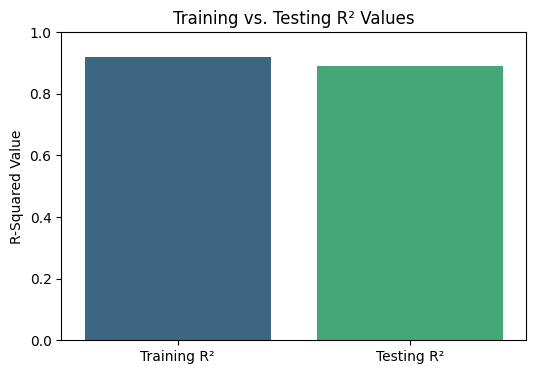

In [16]:
# Bar graph comparing training and testing R² values
plt.figure(figsize=(6, 4))
sns.barplot(x=["Training R²", "Testing R²"], y=[train_r2, test_r2], palette="viridis")
plt.ylim(0, 1)
plt.ylabel("R-Squared Value")
plt.title("Training vs. Testing R² Values")
plt.show()

In [17]:
# Feature Importance Plot
feature_importances = best_rf_model.feature_importances_
features = X.columns
sorted_idx = np.argsort(feature_importances)[::-1]

C:\Users\Acer\AppData\Local\Temp\ipykernel_19052\3866841468.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances[sorted_idx], y=features[sorted_idx], palette="coolwarm")


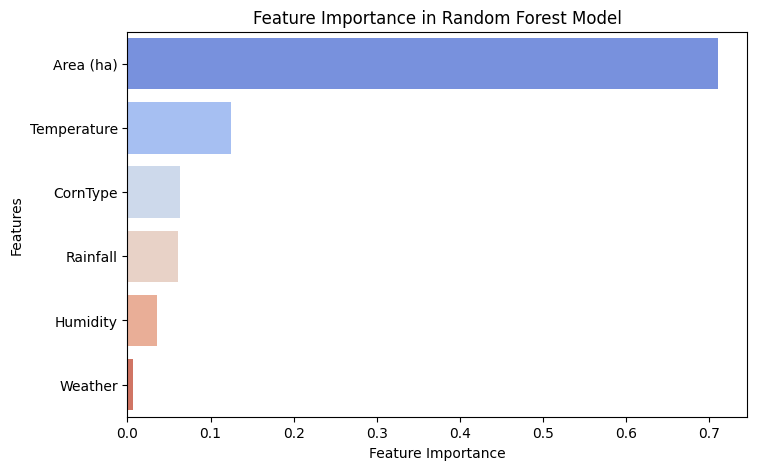

In [18]:


plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importances[sorted_idx], y=features[sorted_idx], palette="coolwarm")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance in Random Forest Model")
plt.show()

In [19]:
joblib.dump(label_encoders['Weather'], "weather_encoder.pkl")
joblib.dump(label_encoders['CornType'], "corn_type_encoder.pkl")

['corn_type_encoder.pkl']

In [20]:
import joblib

joblib.dump(best_rf_model, "corn_yield_model.pkl")
print("Model saved successfully!")


Model saved successfully!
